# Exploring MAEnvs4VRP library


---

## Install

Uncomment the following cells:

In [1]:
#!git clone https://github.com/MAEnvs4VRP/maenvs4vrp.git

In [2]:
# When using Colab
#%cd maenvs4vrp
#!pip install .
#%cd maenvs4vrp/learning_notebooks

This notebook is designed to introduce you to the **MAEnvs4VRP** library through an interactive, step‑by‑step format. You’ll work through a series of concise, hands‑on coding exercises that gradually build your familiarity with the environment’s core features. By the end, you’ll have a solid foundation for leveraging MAEnvs4VRP in your research or applications.

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import torch
import matplotlib.pyplot as plt

## Basic API usage example:

We’ll begin by diving into the Team Orienteering Problem with Time Windows (TOPTW) environment. 

In [5]:
from maenvs4vrp.environments.toptw.env import Environment
from maenvs4vrp.environments.toptw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.toptw.observations import Observations
from maenvs4vrp.environments.toptw.instances_generator import InstanceGenerator
from maenvs4vrp.environments.toptw.env_agent_reward import DenseReward

In [6]:
gen = InstanceGenerator(batch_size = 8)
obs = Observations()
sel = AgentSelector()
rew = DenseReward()

env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

A crucial attribute of the environment is `env.td_state`, which holds the entire state of the simulation and is populated the moment you initialize the environment with `reset()`. Let’s examine the contents of `env.td_state` both before and after calling `reset()`:  

In [7]:
env.td_state

TensorDict(
    fields={
    },
    batch_size=torch.Size([8]),
    device=cpu,
    is_shared=False)

In [8]:
td = env.reset_agent_select_observe(batch_size = 8, num_agents=4, num_nodes=16)

After `reset_agent_select_observe()` the `env.td_state` changes to:

In [9]:
env.td_state

TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action_mask: Tensor(shape=torch.Size([8, 4, 16]), device=cpu, dtype=torch.bool, is_shared=False),
                active_agents_mask: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.bool, is_shared=False),
                cum_profit: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                cur_node_idx: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.int64, is_shared=False),
                cur_profit: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                cur_step: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.int32, is_shared=False),
                cur_time: Tensor(shape=torch.Size([8, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                visited_nodes: Tensor(shape=torch.Size([8, 4, 16]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=t

This top‑level `TensorDict` represents a batch of **8** parallel environments (`batch_size=[8]`). Inside it:

* **`agents`** (TensorDict, `[8,4]` or `[8,4,16]`):

  * Tracks **all 4 agents** per environment:

    * `active_agents_mask` (`[8, 4]`): which agents are still active
    * `cum_profit`, `step_profit` (`[8, 4]`): accumulated and per‑step rewards
    * `cur_node`, `cur_step`, `cur_time` (`[8, 4]`): each agent’s current location index, step count, and timestamp
    * `feasible_nodes`, `visited_nodes` (`[8, 4, 16]`): per‑agent masks over the 16 possible nodes

* **`cur_agent`** (TensorDict, `[8,1]` or `[8,16]`):

  * Details for the **currently acting** agent in each environment:

    * `action_mask` (`[8,16]`): valid node choices
    * `cum_profit`, `step_profit`, `cur_node`, `cur_step`, `cur_time` (`[8,1]`)

* **Global scene tensors**:

  * `coords` (`[8,16,2]`): x,y locations of all 16 nodes
  * `profits`, `service_time`, `time2depot`, `tw_low`, `tw_high` (`[8,16]`): per‑node reward, service duration, travel back to depot, and time‑window bounds
  * `depot_idx`, `depot_loc` (`[8,1]`, `[8,1,2]`): index and coordinates of each environment’s depot
  * `nodes` (TensorDict `[8,16]`):

    * `active_nodes_mask`: which nodes remain unvisited
    * `cur_profits`: remaining reward at each node

* **Control/status flags**:

  * `done`, `is_last_step` (`[8]`): episode termination indicators
  * `is_depot` (`[8,16]`): mask marking which node is the depot

* **Timing & capacity**:

  * `start_time`, `end_time`, `max_tour_duration` (`[8]`): global time settings
  * `time2depot` (`[8,16]`): travel times back to depot

* **`solution`** is an (empty) TensorDict reserved for building the final route outputs.

Together, this structure holds **per-agent**, **per-node**, and **global** information required to step and evaluate each batch of VRP episodes.


Also, as output we have the `TensorDict` `td` containing:

In [10]:
td

TensorDict(
    fields={
        agent_step: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.int32, is_shared=False),
        cur_agent_idx: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([8]), device=cpu, dtype=torch.bool, is_shared=False),
        observations: TensorDict(
            fields={
                action_mask: Tensor(shape=torch.Size([8, 16]), device=cpu, dtype=torch.bool, is_shared=False),
                agent_cur_node_idx: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                agent_obs: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                nodes_static_obs: Tensor(shape=torch.Size([8, 16, 4]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([8]),
            device=cpu,
            is_shared=False),
        penalty: Tensor(shape=torch.Size([8]), device=cpu, dtype

In [11]:
td["done"]

tensor([False, False, False, False, False, False, False, False])

This `TensorDict` summarizes the current state of the environment and includes the observations of active agents across a batch of 8 environments:

**Top-level fields** (shape in brackets is per batch dimension)

- `agent_step` ([8, 1], int32): current step count for the active agent in each environment.  
- `cur_agent_idx` ([8, 1], int64): index of the agent whose turn it is in each environment.  
- `done` ([8], bool): whether each episode has terminated.  
- `penalty` & `reward` ([8], float32): scalar penalty and reward from the last action.  

---

 **`observations`** (nested `TensorDict`, batch size [8])

- `action_mask` ([8, 16], bool): indicates which of the 16 possible node actions are valid for the current agent.  
- `agent_cur_node_idx` ([8, 1], int64): index of the node where the current agent is located.  
- `agent_obs` ([8, 1], float32): feature(s) describing the current agent (e.g., remaining capacity or time, depending on your design).  
- `nodes_static_obs` ([8, 16, 4], float32): per-node static features (e.g., coordinates or other invariant attributes).  




Now we can run an episode:

In [12]:
while not td["done"].all():  
    td = env.sample_action(td) # this is where we insert our policy
    td = env.step_agent_select_observe(td)

at the end we have

In [13]:
td["done"]

tensor([True, True, True, True, True, True, True, True])

and

In [14]:
env.td_state["solution"]

TensorDict(
    fields={
        actions: Tensor(shape=torch.Size([8, 16]), device=cpu, dtype=torch.int64, is_shared=False),
        agents: Tensor(shape=torch.Size([8, 16]), device=cpu, dtype=torch.int64, is_shared=False)},
    batch_size=torch.Size([8]),
    device=cpu,
    is_shared=False)

In [15]:
env.td_state["solution"]["actions"]

tensor([[ 1,  2, 12,  0,  5, 11,  7,  0, 10, 15,  8,  0, 14,  6,  0,  0],
        [ 8,  6,  0, 13,  0,  0,  3, 12,  1,  0,  0,  0,  0,  0,  0,  0],
        [15,  8,  0, 14, 10,  4,  0, 13,  2,  0,  9,  6,  7,  0,  0,  0],
        [ 4, 14,  0, 11,  3,  0,  0, 15,  5, 10,  0,  0,  0,  0,  0,  0],
        [ 9,  7, 13,  0,  5,  4,  0, 12,  0, 11,  1, 15,  0,  0,  0,  0],
        [14,  0,  7,  0,  1, 13,  0,  3,  2,  0,  0,  0,  0,  0,  0,  0],
        [ 2,  3,  5,  0,  4,  1, 12,  0,  9, 11,  7,  0, 15,  6, 14,  0],
        [ 8,  3,  9,  0,  0,  1,  2, 15, 12,  0, 11, 14,  0,  0,  0,  0]])

In [16]:
env.td_state["solution"]["agents"]

tensor([[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 0],
        [0, 0, 0, 1, 1, 2, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 0, 0],
        [0, 0, 0, 1, 1, 1, 2, 3, 3, 3, 3, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 2, 2, 3, 3, 3, 3, 0, 0, 0],
        [0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3],
        [0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 3, 3, 3, 0, 0, 0]])

Together, these two `tensors` give you the full episodic routes for every agent in each environment

## Quick walkthrough

Let's now go through the library's building blocks, exploring their functionalities.

### Instance generation

In [17]:
instance = gen.sample_instance(num_agents=2, num_nodes=10)

In [18]:
instance.keys()

dict_keys(['name', 'num_nodes', 'num_agents', 'data'])

It's also possible to load sets of pre-generated instances, to be used as validation/test sets, which are downloaded on demand from Hugging Face (see the CVRPTW quickstart notebook for an example). For the TOPTW, classical benchmark instances are available:

#### Benchmark instances

In [19]:
from maenvs4vrp.environments.toptw.benchmark_instances_generator import BenchmarkInstanceGenerator

In order to narrow the current gap between the test beds for algorithm benchmarking used in RL
and OR communities, the library allows a straightforward integration of classical OR benchmark
instances. For example, we can load a set of classical benchmark instances. Let's see what benchmark instances we have for the TOPTW:

In [20]:
BenchmarkInstanceGenerator.get_list_of_instances().keys()

maenvs4vrp/environments/toptw/benchmark_instances_generator.py:59: RuntimeWarning: Benchmark instance sets ['Cordeau'] are not available locally. Instantiate BenchmarkInstanceGenerator to download them from HuggingFace ('maenvs4vrp/environments').
  warnings.warn(


dict_keys(['Solomon', 'Cordeau'])

In [21]:
generator = BenchmarkInstanceGenerator(instance_name='Solomon', list_of_instances=['c101', 'c102'])

In [22]:
instance_c101 = generator.get_instance('c101')

In [23]:
instance_c101.keys()

dict_keys(['name', 'num_agents', 'num_nodes', 'data', 'n_digits'])

In [24]:
instance_c101['name']

'c101'

In [25]:
instance_c101['num_agents']

101

In [26]:
instance_c101['num_nodes']

101

###  Observations

Observation features, that will be available to the active agent while interacting with the environment, are handle by `Observations` class. 
The class has a `default_feature_list` attribute where the default configuration dictionary is defined.

In [27]:
obs.default_feature_list

{'nodes_static': {'x_coordinate': {'feat': 'x_coordinate', 'norm': None},
  'y_coordinate': {'feat': 'y_coordinate', 'norm': None},
  'profits': {'feat': 'profits', 'norm': None},
  'is_depot': {'feat': 'is_depot', 'norm': None}},
 'nodes_dynamic': [],
 'agent': ['frac_current_profit'],
 'other_agents': [],
 'all_agents': [],
 'global': ['frac_fleet_load_capacity', 'frac_done_agents']}

Also, five possible features lists exist, detailing the available features in the class: `POSSIBLE_NODES_STATIC_FEATURES`, `POSSIBLE_NODES_DYNAMIC_FEATURES`, `POSSIBLE_SELF_FEATURES`, `POSSIBLE_AGENTS_FEATURES`, `POSSIBLE_GLOBAL_FEATURES`. For example:

In [28]:
obs.POSSIBLE_NODES_STATIC_FEATURES

['x_coordinate',
 'y_coordinate',
 'tw_low',
 'tw_high',
 'profits',
 'service_time',
 'tw_high_minus_tw_low_div_max_dur',
 'x_coordinate_min_max',
 'y_coordinate_min_max',
 'is_depot']

In [29]:
obs.POSSIBLE_GLOBAL_FEATURES

['frac_profits', 'frac_colect_profits', 'frac_done_agents']

While instantiating the `Observations` class, we can pass through a feature list dictionary specifying which features will be available for the agent:

In [30]:
import yaml

In [31]:
feature_list = yaml.safe_load("""
    nodes_static:
        x_coordinate_min_max:
            feat: x_coordinate
            norm: 
        x_coordinate_min_max: 
            feat: x_coordinate
            norm: 
        tw_low_mm:
            feat: tw_low
            norm: 
        tw_high:
            feat: tw_high
            norm: 

    nodes_dynamic:
        - time2open_div_end_time
        - time2close_div_end_time
        
    agent:
        - x_coordinate
        - y_coordinate
        - frac_current_time

    other_agents:
        - x_coordinate
        - y_coordinate
    
    global:
        - frac_done_agents
        - frac_colect_profits
""")

In [32]:
obs = Observations(feature_list)

We can test these observations on the environment:

In [33]:
gen = InstanceGenerator(batch_size=8)
sel = AgentSelector()
rew = DenseReward()

env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

In [34]:
td = env.reset_agent_select_observe(batch_size = 8, num_agents=4, num_nodes=16)

In [35]:
td_observation = env.observe(td)

In [36]:
td_observation

TensorDict(
    fields={
        agent_step: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.int32, is_shared=False),
        cur_agent_idx: Tensor(shape=torch.Size([8, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([8]), device=cpu, dtype=torch.bool, is_shared=False),
        observations: TensorDict(
            fields={
                agent_obs: Tensor(shape=torch.Size([8, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                global_obs: Tensor(shape=torch.Size([8, 2]), device=cpu, dtype=torch.float32, is_shared=False),
                nodes_dynamic_obs: Tensor(shape=torch.Size([8, 16, 2]), device=cpu, dtype=torch.float32, is_shared=False),
                nodes_static_obs: Tensor(shape=torch.Size([8, 16, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                other_agents_obs: Tensor(shape=torch.Size([8, 4, 2]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Si

Let's run an episode:

In [37]:
while not td["done"].all():  
    td = env.sample_action(td) # this is where we insert our policy
    td = env.step_agent_select_observe(td)

and check the collected profits:

In [38]:
env.td_state['agents']['cum_profit'].sum(-1)

tensor([11.,  6., 10.,  7.,  9.,  6., 12.,  9.])

An environment with agents performing random actions is not very impressive. The library includes reference neural solvers in `maenvs4vrp/neuro_solvers`, which can be trained, for example, with the [PPO algorithm](https://spinningup.openai.com/en/latest/algorithms/ppo.html) to get smarter agents:

In [39]:
# When using Colab
#%cd maenvs4vrp/maenvs4vrp/learning_notebooks/

In [40]:
# Training takes a while, so it is commented out. The training scripts currently support the CVRP and TOP environments;
# see maenvs4vrp/neuro_solvers/attention_model/train_ppo.py for all options.
# %run ../neuro_solvers/attention_model/train_ppo.py --vrp_env top --num_agents 4 --num_nodes 21

## Challenges

### Ex0. Warm-up

Ok! Let's now try some small hands-on coding challenges. To simplify solution verification, allowing a pen and paper check, let's use some small toy instances.

In [41]:
from maenvs4vrp.environments.toptw.toy_instance_generator import ToyInstanceGenerator

In [42]:
gen = ToyInstanceGenerator()
obs = Observations()
sel = AgentSelector()
rew = DenseReward()

env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

In [43]:
td = env.reset_agent_select_observe()

The set of service nodes and the depot’s coordinates are as follows:

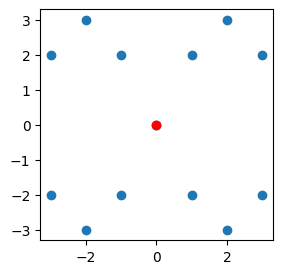

In [44]:
fig = plt.figure(figsize=(3,3))
plt.plot(env.td_state['coords'][0][:,0].numpy(), env.td_state['coords'][0][:,1].numpy(), 'o')
plt.plot(env.td_state['coords'][0][0,0].numpy(), env.td_state['coords'][0][0,1].numpy(), 'o', color='red' )

And the corresponding time‑window constraints are:

In [45]:
for k, data in enumerate(zip(env.td_state['tw_low'][0].tolist(), env.td_state['tw_high'][0].tolist())):
    print(f'node {k} time window is: [{data[0]}; {data[1]}]')

node 0 time window is: [0.0; 12.0]
node 1 time window is: [3.0; 6.0]
node 2 time window is: [4.0; 8.0]
node 3 time window is: [5.0; 9.0]
node 4 time window is: [3.0; 6.0]
node 5 time window is: [4.0; 8.0]
node 6 time window is: [5.0; 9.0]
node 7 time window is: [3.0; 6.0]
node 8 time window is: [4.0; 8.0]
node 9 time window is: [5.0; 9.0]
node 10 time window is: [3.0; 6.0]
node 11 time window is: [4.0; 8.0]
node 12 time window is: [5.0; 9.0]


All agents begin at the depot (node 0, shown as the red dot). The travel times from the depot to each service node are:

In [46]:
loc = env.td_state['coords'].gather(1, env.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
time2j = torch.pairwise_distance(loc, env.td_state["coords"], eps=0, keepdim = False)
time2j[0]

tensor([0.0000, 2.2361, 3.6056, 3.6056, 2.2361, 3.6056, 3.6056, 2.2361, 3.6056,
        3.6056, 2.2361, 3.6056, 3.6056])

I) If the agent selects to visit node 1, what will be the collected profit? 

II) Checking the previous distance values, time windows and the new distances, what will be the mask of the admissible nodes after this step?

(hint: check the `env.td_state` attribute.)

In [47]:
td['next_action'] = torch.tensor([[1]])

In [48]:
td = env.step_agent_select_observe(td)

In [49]:
# %load snippets/ex0.py
# your code here!!

Next, we’ll dive into the **Observations** module:

### Ex1. Team Orienteering Problem with Time Windows - Observations

In [50]:
from maenvs4vrp.environments.toptw.env import Environment
from maenvs4vrp.environments.toptw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.toptw.env_agent_reward import DenseReward

A critical part of training agents is their ability to retrieve useful information from the environment in order to act on it. In **MAEnvs4VRP**, you can tailor exactly what data your agents observe by implementing custom methods in the `Observations` class.

In [51]:
from maenvs4vrp.environments.toptw.observations import Observations

In [52]:
gen = ToyInstanceGenerator()
sel = AgentSelector()
rew = DenseReward()

In [53]:
obs = Observations()

The class has a `default_feature_list` attribute where the default configuration dictionary is defined.

In [54]:
obs.default_feature_list

{'nodes_static': {'x_coordinate': {'feat': 'x_coordinate', 'norm': None},
  'y_coordinate': {'feat': 'y_coordinate', 'norm': None},
  'profits': {'feat': 'profits', 'norm': None},
  'is_depot': {'feat': 'is_depot', 'norm': None}},
 'nodes_dynamic': [],
 'agent': ['frac_current_profit'],
 'other_agents': [],
 'all_agents': [],
 'global': ['frac_fleet_load_capacity', 'frac_done_agents']}

Also, five possible features lists exist, detailing the available features in the class: `possible_nodes_static_features`, `possible_nodes_dynamic_features`, `possible_agent_features`, `possible_agents_features`, `possible_global_features`. For example:

In [55]:
obs.possible_nodes_dynamic_features

['time2open_div_end_time',
 'time2close_div_end_time',
 'arrive2node_div_end_time',
 'time2open_after_step_div_end_time',
 'time2close_after_step_div_end_time',
 'time2end_after_step_div_end_time',
 'fract_time_after_step_div_end_time',
 'reachable_frac_agents']

Lets see how to add another nodes dynamic observation.

I) Change the code below in order to implement the nodes dynamic feature `wait_time_div_end_time`:

In [56]:
# %load snippets/ex1.py
class Observations(Observations):
    
    def __init__(self, feature_list:dict = None):
        super().__init__()
        
        self.default_feature_list['nodes_dynamic'].append('wait_time_div_end_time')
        self.possible_nodes_dynamic_features.append('wait_time_div_end_time')
    
    def get_feat_wait_time_div_end_time(self):
        """ dynamic feature
        Args:

        Returns: 
            Tensor: waiting time at nodes divided by end time.
        """
        loc = self.env.td_state['coords'].gather(1, self.env.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
        ptime = self.env.td_state['cur_agent']['cur_time'].clone()
        time2j = torch.pairwise_distance(loc, self.env.td_state["coords"], eps=0, keepdim = False)
        #arrivej = !! your code here !!
        #wait = !! your code here !!
        return wait / self.env.td_state['end_time'].unsqueeze(dim=-1)
    

In [57]:
obs = Observations(obs)

We can re-check the possible nodes dynamic features available:

In [58]:
obs.possible_nodes_dynamic_features

['time2open_div_end_time',
 'time2close_div_end_time',
 'arrive2node_div_end_time',
 'time2open_after_step_div_end_time',
 'time2close_after_step_div_end_time',
 'time2end_after_step_div_end_time',
 'fract_time_after_step_div_end_time',
 'reachable_frac_agents',
 'wait_time_div_end_time']

and the ones the that are going to used by the agent:

In [59]:
obs.default_feature_list['nodes_dynamic']

['wait_time_div_end_time']

Ok! Now, let's creat the `TOPTW` environment:

In [60]:
env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

II) Check if your answer is correct, by running a couple of environment steps.

Note: the observation feature will be on the `obs.default_feature_list['nodes_dynamic'].index('wait_time_div_end_time')` position of the `node_dynamic_obs` tensor.

In [61]:
#%load snippets/ex2.py
# check the new feature position here

In [62]:
td = env.reset_agent_select_observe(obs_list=["agent_cur_node_idx",'nodes_static', 'action_mask', 'agent', 'nodes_dynamic'])

NameError: name 'wait' is not defined

In [63]:
td

TensorDict(
    fields={
        agent_step: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int32, is_shared=False),
        cur_agent_idx: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        is_last_step: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next_action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        observations: TensorDict(
            fields={
                action_mask: Tensor(shape=torch.Size([1, 13]), device=cpu, dtype=torch.bool, is_shared=False),
                agent_obs: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([1]),
            device=cpu,
            is_shared=False),
        penalty: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),


In [64]:
# %load snippets/ex3.py
td['observations']['nodes_dynamic_obs']

KeyError: 'key "nodes_dynamic_obs" not found in TensorDict with keys [\'action_mask\', \'agent_obs\']'

Now select a node to visit and execute one environment step (you can replace the value `3` with any other valid node index):

In [65]:
td['next_action'] = torch.tensor([[3]])

In [66]:
td = env.step_agent_select_observe(td)

NameError: name 'wait' is not defined

In [67]:
# your code here

In [68]:
# your code here

III) Think of another potentially useful observation feature for this environment. Implement and test it.

In [69]:
# your code here

In [70]:
# your code here

### Ex2. Split Delivery Vehicle Routing Problem with Time Windows (SDVRPTW)

The **Split Delivery Vehicle Routing Problem with Time Windows (SDVRPTW)** extends the classic CVRPTW by allowing each customer’s demand to be split across multiple visits from different vehicles. In other words, a single customer can receive partial deliveries from more than one truck, as long as all time‐window constraints are respected.

Below, we’ll outline the modifications needed to turn our existing CVRPTW environment into an SDVRPTW setup. But first, let’s take a quick look at the CVRPTW environment:

In [71]:
from maenvs4vrp.environments.cvrptw.toy_instance_generator import ToyInstanceGenerator

In [72]:
gen = ToyInstanceGenerator()
inst = gen.sample_instance()

The services and depot location is:

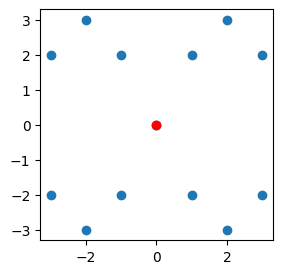

In [73]:
fig = plt.figure(figsize=(3,3))
plt.plot(inst['data']['coords'][0][:,0].numpy(), inst['data']['coords'][0][:,1].numpy(), 'o')
plt.plot(inst['data']['coords'][0][0,0].numpy(), inst['data']['coords'][0][0,1].numpy(), 'o', color='red' )

With time windows and demands:

In [74]:
for k, data in enumerate(zip(inst['data']['tw_low'][0].tolist(), inst['data']['tw_high'][0].tolist(), inst['data']['demands'][0].tolist())):
    print(f'node {k} time window is: [{data[0]}; {data[1]}], with demand {data[2]}')

node 0 time window is: [0.0; 12.0], with demand 0.0
node 1 time window is: [3.0; 6.0], with demand 5.0
node 2 time window is: [4.0; 8.0], with demand 6.0
node 3 time window is: [5.0; 9.0], with demand 4.0
node 4 time window is: [3.0; 6.0], with demand 7.0
node 5 time window is: [4.0; 8.0], with demand 3.0
node 6 time window is: [5.0; 9.0], with demand 4.0
node 7 time window is: [3.0; 6.0], with demand 6.0
node 8 time window is: [4.0; 8.0], with demand 5.0
node 9 time window is: [5.0; 9.0], with demand 3.0
node 10 time window is: [3.0; 6.0], with demand 6.0
node 11 time window is: [4.0; 8.0], with demand 5.0
node 12 time window is: [5.0; 9.0], with demand 4.0


In [75]:
from maenvs4vrp.environments.cvrptw.env import Environment
from maenvs4vrp.environments.cvrptw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.cvrptw.env_agent_reward import DenseReward
from maenvs4vrp.environments.cvrptw.observations import Observations

In [76]:
gen = ToyInstanceGenerator()
sel = AgentSelector()
rew = DenseReward()
obs = Observations()

In [77]:
env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

In [78]:
td = env.reset_agent_select_observe()

I) check what agent is active and what actions are admissible for him.

Note: on the `td` acess `cur_agent_idx` and `observations`/`action_mask` keys.

In [79]:
#%load snippets/ex4.py
# your code here

This information is also available by accessing the environment `td_state` attribute on the `cur_agent` key.

In [80]:
env.td_state['cur_agent']

TensorDict(
    fields={
        action_mask: Tensor(shape=torch.Size([1, 13]), device=cpu, dtype=torch.bool, is_shared=False),
        cum_travel_time: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        cur_load: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        cur_node_idx: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        cur_step: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int32, is_shared=False),
        cur_time: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        cur_travel_time: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([1]),
    device=cpu,
    is_shared=False)

In [81]:
env.td_state['cur_agent']['cur_load']

tensor([[10.]])

Let's choose to serve node `2`:

In [82]:
td['next_action'] = torch.tensor([[2]])
td = env.step_agent_select_observe(td)

In [83]:
action = torch.tensor([[2]])

II) What should the new `cur_load` and `action_mask` be? Check your answer. 

In [84]:
# %load snippets/ex5.py
# your code here

III) What happens if the agents try to serve the node `1`?

In [85]:
# %load snippets/ex6.py
# your code here

OK. Now, lets see what changes are needed to the CVRTPW environment to obtain SDVRPT. we only need to tweak  `_update_curr_agent_feasibility` and `_update_state` methods on the Environment class. Everything else will remain unchanged.


1. **`_update_curr_agent_feasibility`**  
   - **CVRPTW behavior**: Once a customer’s is visited, we mark that node as infeasible for all future visits.  
   - **SDVRPTW change**: Allow a node to remain feasible until its **remaining demand** reaches zero. That means:  
     - Track **remaining demand** at each node (initial demand minus delivered quantity).  
     - In `_update_curr_agent_feasibility`, a node is only masked out when its remaining demand == 0.  

2. **`_update_state`**  
   - **CVRPTW behavior**: When an agent visits node *i*, it:  
     1. Deducts the node’s full demand from the vehicle load.  
     2. Sets that node’s demand to zero.  
   - **SDVRPTW change**: On visiting node *i*, an agent can only deliver up to its remaining vehicle capacity (and no more than the node’s remaining demand). So you must:  
     - Compute `delivered = min(vehicle_capacity, node_remaining_demand)`  
     - Subtract `delivered` from both the vehicle’s load **and** the node’s remaining demand.  
     - If a node’s remaining demand drops to zero, then subsequently `_update_curr_agent_feasibility` will mask it out.  


In [86]:
from maenvs4vrp.environments.sdvrptw.toy_instance_generator import ToyInstanceGenerator
from maenvs4vrp.environments.sdvrptw.env import Environment
from maenvs4vrp.environments.sdvrptw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.sdvrptw.env_agent_reward import DenseReward
from maenvs4vrp.environments.sdvrptw.observations import Observations

In [87]:
gen = ToyInstanceGenerator()
sel = AgentSelector()
rew = DenseReward()
obs = Observations()

Let's start with the `_update_curr_agent_feasibility` method:

In [88]:
# %load snippets/ex7.py
class Environment(Environment):

    def _update_curr_agent_feasibility(self):

        _mask = self.td_state['nodes']['active_nodes_mask'].clone() * self.td_state['cur_agent']['action_mask'].clone()

        # time windows constraints
        loc = self.td_state['coords'].gather(1, self.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
        ptime = self.td_state['cur_agent']['cur_time'].clone()
        time2j = torch.pairwise_distance(loc, self.td_state["coords"], eps=0, keepdim = False)
        if self.n_digits is not None:
            time2j = torch.floor(self.n_digits * time2j) / self.n_digits
        arrivej = ptime + time2j
        waitj = torch.clip(self.td_state['tw_low']-arrivej, min=0)
        service_startj = arrivej + waitj

        c1 = service_startj <= self.td_state['tw_high']
        c2 = service_startj + self.td_state['service_time'] + self.td_state['time2depot'] <= self.td_state['end_time'].unsqueeze(-1)

        # capacity constraints (if there is no load, the agent can only return to the depot)
        c3 = torch.ones_like(_mask, dtype=torch.bool, device=self.device)
        c3[self.td_state['cur_agent']['cur_load'].le(0).squeeze(-1)] = False
        c3[self.td_state['cur_agent']['cur_load'].le(0).squeeze(-1), self.td_state['depot_idx']] = True
        
        _mask = _mask * c1 * c2 * c3
        # update state
        self.td_state['cur_agent'].update({'action_mask': _mask}) 
        self.td_state['agents']['action_mask'].scatter_(1, 
                                            self.td_state['cur_agent_idx'][:,:,None].expand(-1,-1,self.num_nodes), _mask.unsqueeze(1))

Now the `_update_state` method:

In [89]:
# %load snippets/ex8.py
class Environment(Environment):

    def _update_state(self, action):
        loc = self.td_state['coords'].gather(1, self.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
        next_loc = self.td_state['coords'].gather(1, action[:,:,None].expand(-1, -1, 2))

        ptime = self.td_state['cur_agent']['cur_time'].clone()
        time2j = torch.pairwise_distance(loc, next_loc, eps=0, keepdim = False)
        if self.n_digits is not None:
            time2j = torch.floor(self.n_digits * time2j) / self.n_digits
        tw = self.td_state['tw_low'].gather(1, action)
        service_time = self.td_state['service_time'].gather(1, action)

        arrivej = ptime + time2j
        waitj = torch.clip(tw-arrivej, min=0)

        time_update = arrivej + waitj + service_time
        # update agent cur node
        self.td_state['cur_agent']['cur_node_idx'] = action
        self.td_state['agents']['cur_node_idx'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cur_node_idx'])
        # update agent cur time
        self.td_state['cur_agent']['cur_time'] = time_update

        # is agent is done set agent time to end_time
        agents_done = ~self.td_state['agents']['active_agents_mask'].gather(1, self.td_state['cur_agent_idx']).clone()
        self.td_state['cur_agent']['cur_time'] = torch.where(agents_done, self.td_state['end_time'].unsqueeze(-1), 
                                                             self.td_state['cur_agent']['cur_time'])
        self.td_state['agents']['cur_time'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cur_time'])

        # update agent cum traveled time
        self.td_state['cur_agent']['cur_travel_time'] = time2j
        self.td_state['cur_agent']['cum_travel_time'] += time2j
        self.td_state['agents']['cur_travel_time'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cur_travel_time'])
        self.td_state['agents']['cum_travel_time'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cum_travel_time'])

        # update agent load and node demands
        #cur_demands = !!your code here!!
        #current_load = !!your code here!!
        #load_transfer =  !!your code here!!

        self.td_state['cur_agent']['cur_load'] -= load_transfer

        # if agent is done set agent cur_load to 0
        self.td_state['cur_agent']['cur_load'] = torch.where(agents_done, 0., 
                                                             self.td_state['cur_agent']['cur_load'])
        
        self.td_state['nodes']['cur_demands'].scatter_(1, action, cur_demands-load_transfer)
        # update done nodes
        self.td_state['nodes']['active_nodes_mask'] = self.td_state['nodes']['cur_demands'].gt(0)
        self.td_state['nodes']['active_nodes_mask'].scatter_(1, self.td_state['depot_idx'], True)

        self.td_state['agents']['cur_load'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cur_load'])
        # update visited nodes
        r = torch.arange(*self.td_state.batch_size, device=self.device)
        self.td_state['agents']['visited_nodes'][r, self.td_state['cur_agent_idx'].squeeze(-1), action.squeeze(-1)] = True
        # update agent step
        self.td_state['cur_agent']['cur_step'] = torch.where(~agents_done, self.td_state['cur_agent']['cur_step']+1, 
                                                             self.td_state['cur_agent']['cur_step'])
        self.td_state['agents']['cur_step'].scatter_(1, self.td_state['cur_agent_idx'], self.td_state['cur_agent']['cur_step'])

        # if all done activate first agent to guarantee batch consistency during agent sampling
        self.td_state['agents']['active_agents_mask'][self.td_state['agents']['active_agents_mask'].sum(1).eq(0), 0] = True


Let's test the environment, and repeat the steps we have performed for de CVRPTW:

In [90]:
env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

In [91]:
td = env.reset_agent_select_observe()

In [92]:
td['next_action'] = torch.tensor([[2]])
td = env.step_agent_select_observe(td)

NameError: name 'load_transfer' is not defined

In [93]:
env.td_state['cur_agent']['action_mask']

tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True]])

In [94]:
env.td_state['cur_agent']['cur_load']

tensor([[10.]])

IV) What happens if the agents now goes the node `1`?

In [95]:
# %load snippets/ex9.py
# your code here

V) What should the new `cur_load`, `action_mask` and nodes `cur_demands` be? Check your answer. 

In [96]:
# %load snippets/ex10.py
# your code here

It seems to be working!

### Ex3. Capacitated Vehicle Routing Problem with Soft Time Windows (CVRPSTW)

In this variation of the CVRPTW, time window constraints are relaxed and can be violated at a penalty cost (usually linear proportional to the interval between opening/closing times and vehicle arrival). Although the penalty function can be defined in several ways, we consider the formulation studied in [M. A. Figliozzi](https://www.sciencedirect.com/science/article/abs/pii/S0968090X09001119)). 
Concretely, the time window violation cannot exceed $P_{max}$, and consequently, for each customer, we can enlarge its time window to $[o_i - P_{max}, c_i + P_{max}] = [o^s_i , c^s_i]$ outside which the service cannot be performed. When a vehicle arrives at a customer at time $t_i \in [o^s_i , c^s_i]$, it can have an early arrival penalty cost of $p_e \max (o_i-t_i,0)$ and a late arrival penalty cost of $p_l \max (t_i-c_i, 0)$.

Furthermore, the vehicle's maximum waiting time at any customer, $W_{max}$, is imposed. That is, the vehicles can only arrive at each customer after $o_i - P_{max} - W_{max}$, so that its waiting time doesn't exceed $W_{max}$.

The environment for this problem has already been almost done for us. Compared to the base CVRPTW environment, `early_penalty` and `late_penalty` attributes were added to the environment and `tw_high_limit`, `tw_high_limit`, `arrive_limit` attributes were added to `td_state`.

In [97]:
from maenvs4vrp.environments.cvrpstw.env import Environment
from maenvs4vrp.environments.cvrpstw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.cvrpstw.observations import Observations
from maenvs4vrp.environments.cvrpstw.toy_instance_generator import ToyInstanceGenerator
from maenvs4vrp.environments.cvrpstw.env_agent_reward import DenseReward

In [98]:
gen = ToyInstanceGenerator()
sel = AgentSelector()
rew = DenseReward()
obs = Observations()

II) Complete the `_update_curr_agent_feasibility` method in order to take into account the waiting time constraint:

In [99]:
%load snippets/ex11.py
class Environment(Environment):
 
    def _update_curr_agent_feasibility(self):

        _mask = self.td_state['nodes']['active_nodes_mask'].clone() * self.td_state['cur_agent']['action_mask'].clone()

        # time windows constraints
        loc = self.td_state['coords'].gather(1, self.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
        ptime = self.td_state['cur_agent']['cur_time'].clone()
        time2j = torch.pairwise_distance(loc, self.td_state["coords"], eps=0, keepdim = False)
        if self.n_digits is not None:
            time2j = torch.floor(self.n_digits * time2j) / self.n_digits

        arrivej = ptime + time2j
        waitj = torch.clip(self.td_state['tw_low_limit']-arrivej, min=0)
        service_startj = arrivej + waitj

        #c0 = !! your code here !! # agents can only arrive at each customer after $o_i - P_{max} - W_{max}$
        c1 = service_startj <= self.td_state['tw_high_limit']
        c2 = service_startj + self.td_state['service_time'] + self.td_state['time2depot'] <= self.td_state['end_time'].unsqueeze(-1)

        # capacity constraints
        c3 = self.td_state['demands'] <= self.td_state['cur_agent']['cur_load']

        _mask = _mask * c0 * c1 * c2 * c3
        # update state
        self.td_state['cur_agent'].update({'action_mask': _mask}) 
        self.td_state['agents']['action_mask'].scatter_(1, 
                                            self.td_state['cur_agent_idx'][:,:,None].expand(-1,-1,self.num_nodes), _mask.unsqueeze(1))


II) Complete the the `DenseReward` class in order to take into acount the penalty for time windows violation:

(hint: check `td_state['cur_agent']['cur_penalty']` )

In [100]:
#%load snippets/ex12.py
class DenseReward(DenseReward):
    """Reward class.
    """

    def get_reward(self, action):
        """
        
        """

        # your code here!!
    
        return reward, penalty

In [101]:
rew = DenseReward()

In [102]:
env = Environment(instance_generator_object=gen,  
                  obs_builder_object=obs,
                  agent_selector_object=sel,
                  reward_evaluator=rew,
                  seed=0)

In [103]:
td = env.reset_agent_select_observe()

NameError: name 'c0' is not defined

Let's get some information about the environment:

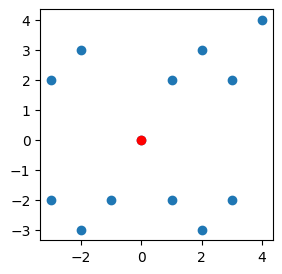

In [104]:
fig = plt.figure(figsize=(3,3))
plt.plot(env.td_state['coords'][0][:,0].numpy(), env.td_state['coords'][0][:,1].numpy(), 'o')
plt.plot(env.td_state['coords'][0][0,0].numpy(), env.td_state['coords'][0][0,1].numpy(), 'o', color='red' )

In [105]:
for k, data in enumerate(zip(env.td_state['tw_low'][0].tolist(), env.td_state['tw_high'][0].tolist(), env.td_state['demands'][0].tolist())):
    print(f'node {k} time window is: [{data[0]}; {data[1]}], with demand {data[2]}')

node 0 time window is: [0.0; 12.0], with demand 0.0
node 1 time window is: [3.0; 6.0], with demand 5.0
node 2 time window is: [4.0; 8.0], with demand 6.0
node 3 time window is: [5.0; 9.0], with demand 4.0
node 4 time window is: [7.0; 9.0], with demand 7.0
node 5 time window is: [4.0; 8.0], with demand 3.0
node 6 time window is: [5.0; 9.0], with demand 4.0
node 7 time window is: [3.0; 6.0], with demand 6.0
node 8 time window is: [4.0; 8.0], with demand 5.0
node 9 time window is: [5.0; 9.0], with demand 3.0
node 10 time window is: [3.0; 6.0], with demand 6.0
node 11 time window is: [4.0; 8.0], with demand 5.0
node 12 time window is: [5.0; 9.0], with demand 4.0


In [106]:
for k, data in enumerate(zip(env.td_state['tw_low_limit'][0].tolist(), env.td_state['tw_high_limit'][0].tolist(), env.td_state['arrive_limit'][0].tolist())):
    print(f'node {k} time window limit is: [{data[0]:.2f}; {data[1]:.2f}], with arrive time limit {data[2]:.2f}')

node 0 time window limit is: [-1.20; 13.20], with arrive time limit -2.40
node 1 time window limit is: [1.80; 7.20], with arrive time limit 0.60
node 2 time window limit is: [2.80; 9.20], with arrive time limit 1.60
node 3 time window limit is: [3.80; 10.20], with arrive time limit 2.60
node 4 time window limit is: [5.80; 10.20], with arrive time limit 4.60
node 5 time window limit is: [2.80; 9.20], with arrive time limit 1.60
node 6 time window limit is: [3.80; 10.20], with arrive time limit 2.60
node 7 time window limit is: [1.80; 7.20], with arrive time limit 0.60
node 8 time window limit is: [2.80; 9.20], with arrive time limit 1.60
node 9 time window limit is: [3.80; 10.20], with arrive time limit 2.60
node 10 time window limit is: [1.80; 7.20], with arrive time limit 0.60
node 11 time window limit is: [2.80; 9.20], with arrive time limit 1.60
node 12 time window limit is: [3.80; 10.20], with arrive time limit 2.60


For the active agent in the depot, the times (distances) to customers will be:

In [107]:
loc = env.td_state['coords'].gather(1, env.td_state['cur_agent']['cur_node_idx'][:,:,None].expand(-1, -1, 2))
time2j = torch.pairwise_distance(loc, env.td_state["coords"], eps=0, keepdim = False)
time2j[0]

tensor([0.0000, 2.2361, 3.6056, 3.6056, 5.6569, 3.6056, 3.6056, 2.2361, 3.6056,
        3.6056, 2.2361, 3.6056, 3.6056])

I) Make some environment steps to check if our implementation is correct. 

II) What `reward` and `penalty` values are expected?

In [108]:
# %load snippets/ex13.py

In [109]:
# your code here

In [110]:
# your code here

In [111]:
# your code here

Let's do an episode rollout and check the `reward` and `penalty` through every step:

In [112]:
td = env.reset_agent_select_observe()
while not td["done"].all():  
    td = env.sample_action(td) 
    td = env.step_agent_select_observe(td)
    step = env.env_nsteps
    reward = td['reward']
    penalty = td['penalty']
    print(f'env step number:{step}, reward: {reward}, penalty: {penalty}')

NameError: name 'c0' is not defined


**Well done! That's it for today. For any comments and suggestions, please drop us an email.**

---